In [30]:
import pandas as pd

In [31]:
dataset_path = '../../datasets/spotify_classification.csv'

In [32]:
df = pd.read_csv(dataset_path, delimiter=',')
df.head(2)

,id,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,target,song_title,artist
0,0,0.0102,0.833,204600,0.434,0.02190,2,0.165,-8.795,1,0.4310,150.062,4.0,0.286,1,Mask Off,Future
1,1,0.1990,0.743,326933,0.359,0.00611,1,0.137,-10.401,1,0.0794,160.083,4.0,0.588,1,Redbone,Childish Gambino


In [33]:
columns = [
    'energy',
    'artist'
]

df = df[columns]
df = pd.get_dummies(df)
df = df.dropna()
df.head(2)

,energy,artist_!!!,artist_*NSYNC,artist_10cm,artist_2 Chainz,artist_2 LIVE CREW,artist_20th Century Steel Band,artist_21 Savage,artist_2milly,artist_3LW,...,artist_alt-J,artist_deadmau5,artist_for KING & COUNTRY,artist_one sonic society,artist_tUnE-yArDs,artist_tobyMac,artist_권나무 Kwon Tree,artist_도시총각 Dosichonggak,artist_카우칩스 The CowChips,artist_플랫핏 Flat Feet
0,0.434,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,0.359,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [34]:
from sklearn.cluster import KMeans
from math import sqrt

In [35]:
def calculate_wcss(data):
    wcss = []
    for n in range(2, 21):
        kmeans = KMeans(n_clusters=n)
        kmeans.fit(X=data)
        wcss.append(kmeans.inertia_)

    return wcss

In [36]:
def optimal_number_of_clusters(wcss):
    x1, y1 = 2, wcss[0]
    x2, y2 = 20, wcss[len(wcss)-1]

    distances = []
    for i in range(len(wcss)):
        x0 = i+2
        y0 = wcss[i]
        numerator = abs((y2-y1)*x0 - (x2-x1)*y0 + x2*y1 - y2*x1)
        denominator = sqrt((y2 - y1)**2 + (x2 - x1)**2)
        distances.append(numerator/denominator)
    
    return distances.index(max(distances)) + 2

In [37]:
sum_of_squares = calculate_wcss(df)
n_clusters = optimal_number_of_clusters(sum_of_squares)

# kmeans = KMeans(n_clusters=n_clusters)
# clusters = kmeans.fit_predict(df)

model = KMeans(n_clusters=n_clusters)
model.fit(df)
group = model.predict(df)

group

array([ 3, 14,  3, ..., 12, 12, 12], shape=(2017,), dtype=int32)

In [38]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_array = pca.fit_transform(df)

df_pca = pd.DataFrame(data=pca_array, index=df.index.copy())
df_pca.columns = ['PC' + str(col+1) for col in df_pca.columns.values]
df_pca['group'] = group

df_pca.head()

,PC1,PC2,group
0,-0.264052,-0.022778,3
1,-0.323259,-0.015328,14
2,-0.285856,-0.023286,3
3,-0.342769,-0.019716,14
4,-0.121198,-0.009875,1


ValueError: 'c' argument must be a color, a sequence of colors, or a sequence of numbers, not 0       #876E03
1           NaN
2       #876E03
3           NaN
4       #425B26
         ...   
2012        NaN
2013        NaN
2014        NaN
2015        NaN
2016        NaN
Name: color, Length: 2017, dtype: object

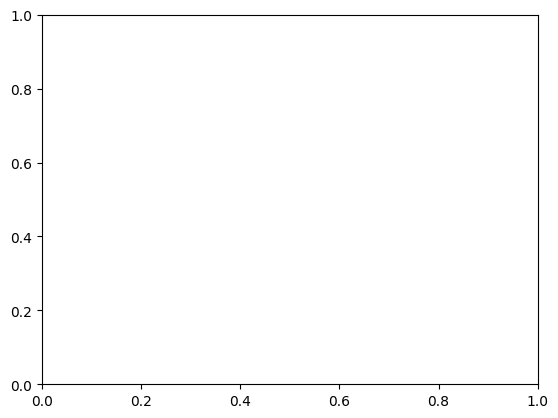

In [ ]:
import matplotlib.pyplot as plt

colors = ['#5DF534', '#425B26', '#151716', '#876E03', '#E8CECF', '#023411', '#042E54', '#2572D3', '#FD0D0C', '#169C90']
df_pca['color'] = df_pca['group'].map({0:colors[0], 1:colors[1], 2:colors[2], 3:colors[3], 4:colors[4], 5:colors[5], 6:colors[6], 7:colors[7], 8:colors[8], 9:colors[9]})

plt.scatter(df_pca['PC1'], df_pca['PC2'], c=df_pca['color'], alpha = 0.6, s=10)

In [ ]:
from mpl_toolkits import mplot3d

colors = ['#5DF534', '#425B26', '#151716', '#876E03', '#E8CECF', '#023411', '#042E54', '#2572D3', '#FD0D0C', '#169C90']
df_pca['color'] = df_pca['group'].map({0:colors[0], 1:colors[1], 2:colors[2], 3:colors[3], 4:colors[4], 5:colors[5], 6:colors[6], 7:colors[7], 8:colors[8], 9:colors[9]})

fig = plt.figure(figsize = (10, 7))
ax = plt.axes(projection ="3d")
ax.scatter3D(df_pca['PC1'], df_pca['PC2'], df_pca['PC3'], c=df_pca['color'])

plt.show()

In [ ]:
# import joblib

In [ ]:
# joblib.dump(model, 'house_price_linear_regression_model.pkl')